<a href="https://colab.research.google.com/github/ethanboyjeff/ELE2038-Coursework/blob/main/ELE2038_CW_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Equilibrium: x = 0.5 m, i = 0.6988 A, V = 1537.39 V


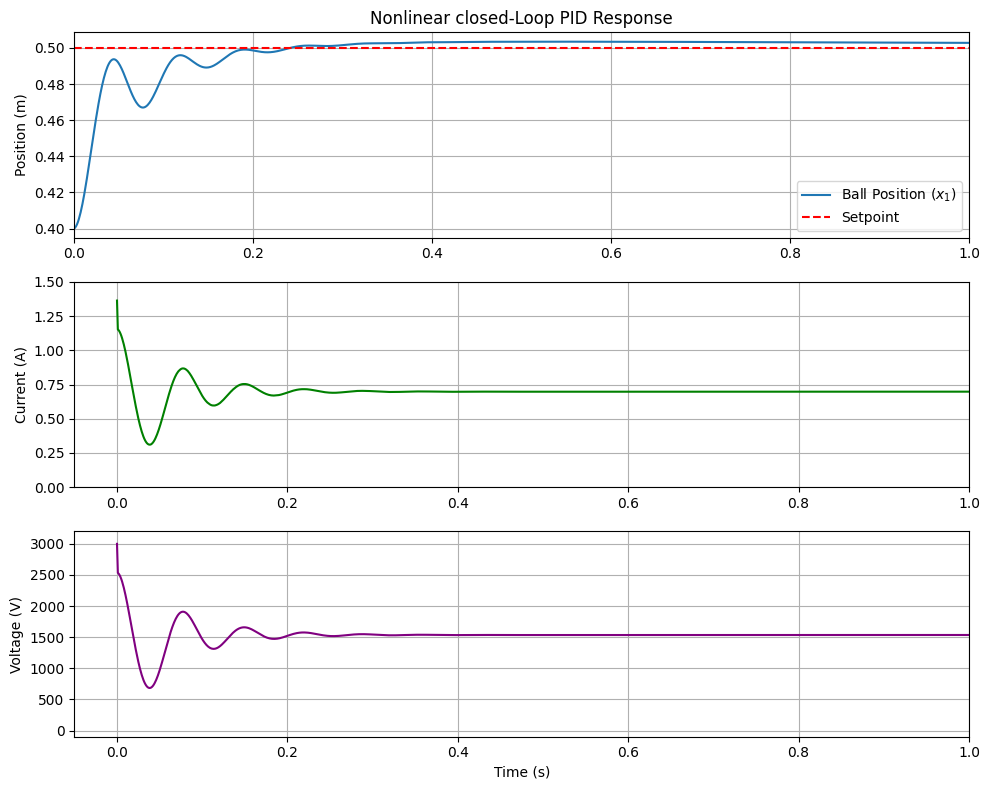

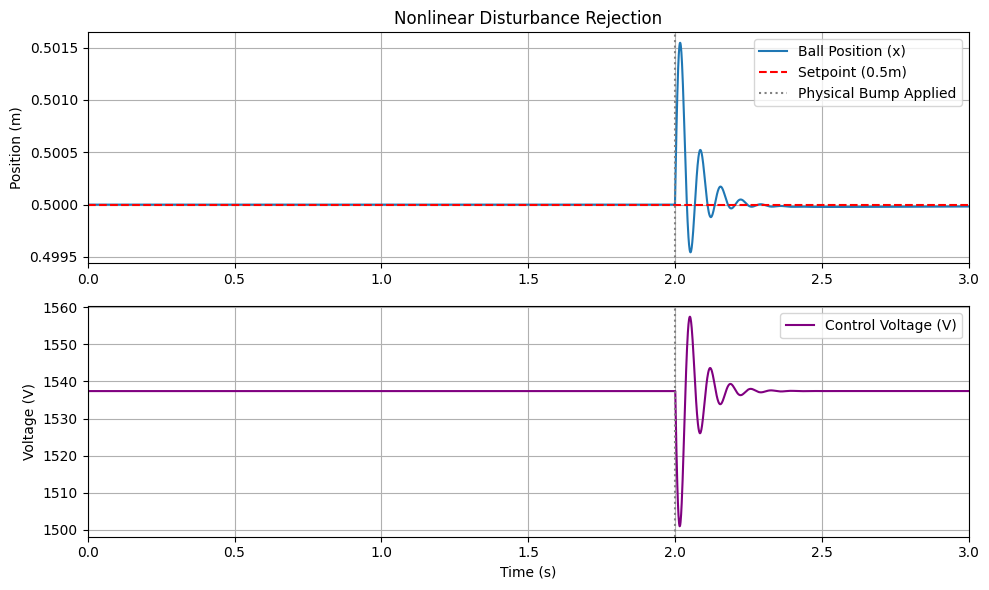

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import StateSpace, lsim, TransferFunction

# 1. System Parameters
m = 0.462
g = 9.81
r = 0.123
k = 1885.0
b = 10.4
d = 0.42
delta = 0.65
phi = np.deg2rad(41) # 41 degrees
R = 2200.0
L0 = 0.125
L1 = 0.0241
alpha = 1.2
c = 6.811       # Magnetic constant
tau_m = 0.03    # Sensor time constant
Km = 1.0        # Sensor (DC) gain

# Derived effective mass for a rolling sphere
m_eff = (7/5) * m

# 2. Operating Point / Equilibrium
x_sp = 0.5    # Setpoint position (m)
# Mechanical equilibrium to find i_eq
# F_mag = mg*sin(phi) + k(x - d)
f_grav_spring = k*(x_sp - d) - m*g*np.sin(phi)
i_eq = np.sqrt(f_grav_spring * (delta - x_sp)**2 / c)
V_eq = R * i_eq # Voltage at equilibrium

print(f"Equilibrium: x = {x_sp} m, i = {i_eq:.4f} A, V = {V_eq:.2f} V")

# 3. Nonlinear System ODEs
def system_dynamics(t, state, u):
    x1, x2, x3 = state

    # State 1 Derivative (Velocity)
    x1_dot = x2

    # State 2 Derivative (Acceleration)
    x2_dot = (5/(7*m))*(m*g*np.sin(phi) + (c*(x3**2)/(delta-x1)**2) - k*(x1-d) - b*x2)

    # State 3 Derivative (Current) - including the back-EMF term!
    dLdx = L1 * alpha * np.exp(-alpha*(delta-x1))
    x3_dot = (u - x3*R - x3*dLdx*x2) / (L0 + L1*np.exp(-alpha*(delta-x1)))

    return [x1_dot, x2_dot, x3_dot]

# 4. PID Controller Implementation
# Based on design requirements: OS < 10%, Settling < 2s
Kp = 10000.0
Ki = 5000
Kd = 850.0

# By implementing a time-step loop, we can actively compute a new control
# voltage (V_control) at every millisecond using this pid_control function
def pid_control(t, state, integral_error, last_error):
    x = state[0]
    error = x_sp - x
    dt = 0.001 # Approximation for derivative

    prop = Kp * error
    integ = Ki * (integral_error + error * dt)
    deriv = Kd * (error - last_error) / dt

    V_control = V_eq + prop + integ + deriv
    return np.clip(V_control, 0, 3000), error # Clip to realistic voltage

# 5. Revised Simulation Loop with PID
dt = 0.001
t_final = 5
time_steps = np.arange(0, t_final, dt)

# Initialize tracking variables
integral_error = 0
last_error = 0
current_state = [0.40, 0, i_eq]
              # [actual_x, velocity, current, measured_x]

# Initialize the separate digital sensor
current_measured_x = 0.40

# Storage for plotting
history_t = []
history_x1 = [] # Position
history_x2 = [] # Velocity
history_x3 = [] # Current
history_u = []  # COntrol Voltage

for t in time_steps:

    # 1. Read the sensor (State variable x4)
    actual_x = current_state[0]

    # Update the delayed sensor reading
    sensor_derivative = (Km * actual_x - current_measured_x) / tau_m
    current_measured_x += sensor_derivative * dt


    # 2. Calculate the PID Error terms
    error = x_sp - current_measured_x
    integral_error += error * dt
    derivative_error = (error - last_error) / dt

    # 3. Calculate PID Output
    pid_output = Kp * error + Ki * integral_error + Kd * derivative_error

    # 4. Calculate the total control voltage (Equilibrium + PID adjustment)
    u = V_eq + pid_output

    # 5. Clip the voltage to match real-world power supply limits
    u = np.clip(u, -100, 3000)

    # 6. Run the simulation for this millisecond using u
    sol = solve_ivp(system_dynamics, [t, t + dt], current_state, args=(u,))

    # 2. Update error terms for next iteration
    last_error = error
    current_state = sol.y[:, -1]

    # 4. Save results and update current state
    history_t.append(t)
    history_x1.append(current_state[0])
    history_x2.append(current_state[1])
    history_x3.append(current_state[2])
    history_u.append(u)

# Convert to arrays for plotting
history_t = np.array(history_t)
history_x1 = np.array(history_x1)
history_x2 = np.array(history_x2)
history_x3 = np.array(history_x3)
history_u = np.array(history_u)

# 6. Plotting Results
plt.figure(figsize=(10, 8))

# Position Plot
plt.subplot(3, 1, 1)
plt.plot(history_t, history_x1, label='Ball Position ($x_1$)')
plt.axhline(y=x_sp, color='r', linestyle='--', label='Setpoint')
plt.ylabel('Position (m)')
plt.title('Nonlinear closed-Loop PID Response')
plt.xlim(0, 1.0)
plt.legend(loc = 'lower right'); plt.grid(True)

# Current Plot
plt.subplot(3, 1, 2)
plt.plot(history_t, history_x3, color='green', label='Current ($x_3$)')
plt.ylabel('Current (A)')
plt.xlim(-0.05, 1.0)
plt.ylim(0, 1.5)
plt.grid(True)

# Control Voltage Plot (Important to check for saturation)
plt.subplot(3, 1, 3)
plt.plot(history_t, history_u, color='purple', label='Control Voltage ($u$)')
plt.ylabel('Voltage (V)')
plt.xlabel('Time (s)')
plt.xlim(-0.05, 1.0)
plt.ylim(-100, 3200)
plt.grid(True)

plt.tight_layout()
plt.savefig('nonlinear_response.png', dpi=300, bbox_inches='tight')
plt.show()


# 7. Disturbance Rejection Test
# Run for 4 seconds.
t_final_dist = 4.0
time_steps_dist = np.arange(0, t_final_dist, dt)

# Start already settled AT the setpoint (0.44m) and at equilibrium current
current_state = [x_sp, 0, i_eq]
current_measured_x = x_sp

integral_error = 0
last_error = 0

history_t_dist = []
history_x_dist = []
history_v_dist = []

for t in time_steps_dist:
    # INJECT DISTURBANCE: At exactly t = 2.0s, give the ball a sudden physical bump
    # This instantly changes its velocity by 0.15 m/s down the ramp
    if abs(t - 2.0) < dt/2:
        current_state[1] += 0.15

    actual_x = current_state[0]

    sensor_derivative = (Km * actual_x - current_measured_x) / tau_m
    current_measured_x += sensor_derivative * dt

    error = x_sp - current_measured_x
    integral_error += error * dt
    deriv = (error - last_error) / dt

    v_out = V_eq + Kp * error + Ki * integral_error + Kd * deriv
    v_out = np.clip(v_out, -100, 3000)

    # 3. Simulate one step
    sol = solve_ivp(system_dynamics, [t, t + dt], current_state, args=(v_out,))

    # 4. Save results
    current_state = sol.y[:, -1]
    last_error = error
    history_t_dist.append(t)
    history_x_dist.append(current_state[0])
    history_v_dist.append(v_out)

# Plotting the Disturbance Rejection
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(history_t_dist, history_x_dist, label='Ball Position (x)')
plt.axhline(y=x_sp, color='r', linestyle='--', label='Setpoint (0.5m)')
plt.axvline(x=2.0, color='grey', linestyle=':', label='Physical Bump Applied')
plt.ylabel('Position (m)')
plt.title('Nonlinear Disturbance Rejection')
plt.legend()
plt.xlim(0, 3)
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(history_t_dist, history_v_dist, color='purple', label='Control Voltage (V)')
plt.axvline(x=2.0, color='grey', linestyle=':')
plt.ylabel('Voltage (V)')
plt.xlabel('Time (s)')
plt.legend()
plt.xlim(0, 3)
plt.grid(True)

plt.tight_layout()
plt.savefig('nonlinear_disturbance_response.png', dpi=300, bbox_inches='tight')
plt.show()


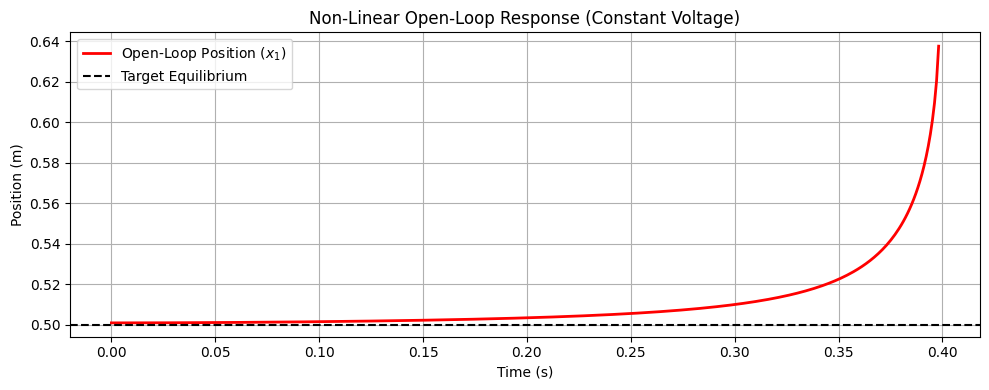

In [35]:
# OPEN-LOOP SIMULATION
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# 1. New calculations
x_sp_ol = 0.5
f_grav_spring_ol = k*(x_sp_ol - d) - m*g*np.sin(phi)
i_eq_ol = np.sqrt(f_grav_spring_ol * (delta - x_sp_ol)**2 / c)
V_eq_ol = i_eq_ol * R

# 2. Apply the strictly constant baseline voltage
u_open_loop = V_eq_ol

# 3. Start EXACTLY at equilibrium, but add a 1mm disturbance CLOSER to the magnet
initial_state_ol = [x_sp_ol + 0.001, 0.0, i_eq_ol]

# 4. Run the physics non-stop
sol_ol = solve_ivp(system_dynamics,
                   [0, 2.0],
                   initial_state_ol,
                   t_eval=np.linspace(0, 2.0, 2000),
                   args=(u_open_loop,))

# 5. Extract and Plot
history_t_ol = sol_ol.t
history_x1_ol = sol_ol.y[0]

plt.figure(figsize=(10, 4))
plt.plot(history_t_ol, history_x1_ol, color='red', linewidth=2, label='Open-Loop Position ($x_1$)')
plt.axhline(y=x_sp_ol, color='k', linestyle='--', label='Target Equilibrium')

plt.ylabel('Position (m)')
plt.xlabel('Time (s)')
plt.title('Non-Linear Open-Loop Response (Constant Voltage)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('nonlinear_openloop_response.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
import numpy as np
from scipy.signal import StateSpace

# 1. Calculate the specific matrix components from handwritten notes

x_sp_values = [0.44, 0.49, 0.5]

for x_sp in x_sp_values:
      f_grav_spring = k*(x_sp - d) - m*g*np.sin(phi)
      i_sp = np.sqrt(f_grav_spring * (delta - x_sp)**2 / c)

      print(f"Operating Point: x_sp = {x_sp} m, i_sp = {i_sp:.4f} A")

      L_sp = L0 + L1 * np.exp(-alpha * (delta - x_sp))

      a21 = (5 / (7 * m)) * ((2 * c * i_sp**2) / (delta - x_sp)**3 - k)
      a22 = - (5 * b) / (7 * m)
      a23 = (5 / (7 * m)) * ((2 * c * i_sp) / (delta - x_sp)**2)

      a33 = - R / L_sp
      a41 = Km / tau_m
      a44 = - 1 / tau_m

      # 2. Build the Matrices (A, B, C, D)
      A = np.array([
          [0,     1,   0,   0],
          [a21, a22, a23,   0],
          [0,     0, a33,   0],
          [a41,   0,   0, a44]
      ])

      B = np.array([
          [0],
          [0],
          [1 / L_sp],
          [0]
      ])

      # C matrix defines the output (we want the 4th state, x_m)
      C = np.array([[0, 0, 0, 1]])

      # D matrix is zero (no direct feedthrough from voltage to sensor)
      D = np.array([[0]])

      # 3. Create the Linear State-Space System
      linear_sys = StateSpace(A, B, C, D)

      # 4. Prove Stability by calculating the poles
      poles = linear_sys.poles

      print("System Poles:")
      for i, pole in enumerate(poles):
          # Format the poles to 4 decimal places
          if np.iscomplex(pole):
              print(f"  λ{i+1} = {np.real(pole):.4f} ± {np.abs(np.imag(pole)):.4f}j")
          else:
              print(f"  λ{i+1} = {np.real(pole):.4f}")

      print("\n") # Add a blank line between runs for readability

Operating Point: x_sp = 0.44 m, i_sp = 0.4742 A
System Poles:
  λ1 = -15306.3072
  λ2 = -8.0396 ± 48.3568j
  λ3 = -8.0396 ± 48.3568j
  λ4 = -33.3333


Operating Point: x_sp = 0.49 m, i_sp = 0.6963 A
System Poles:
  λ1 = -15183.9436
  λ2 = -33.3333
  λ3 = -8.0396 ± 18.8977j
  λ4 = -8.0396 ± 18.8977j


Operating Point: x_sp = 0.5 m, i_sp = 0.6988 A
System Poles:
  λ1 = -15158.8219
  λ2 = -33.3333
  λ3 = -22.0977
  λ4 = 6.0185




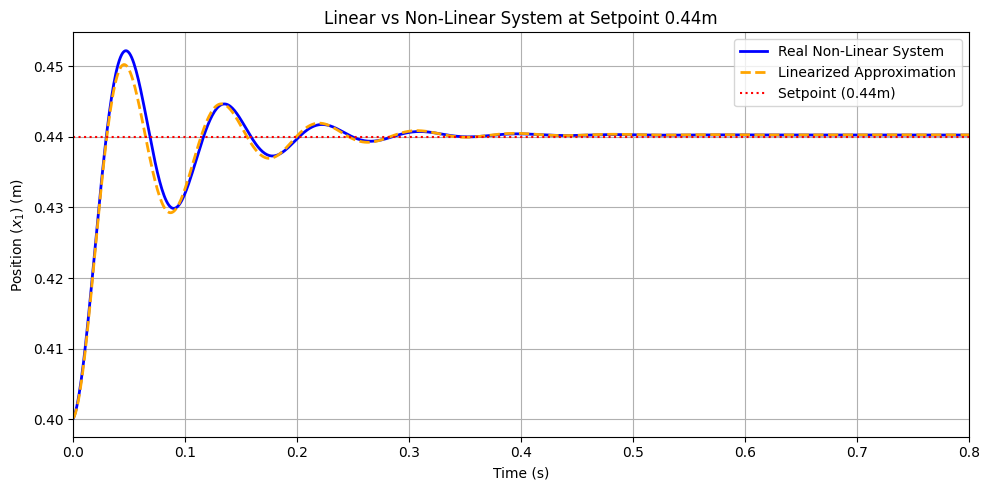

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

x_sp = 0.44  # Target Setpoint
start_x = x_sp - 0.04 # Drop from 0.40m

f_grav_spring = k*(x_sp - d) - m*g*np.sin(phi)
i_eq = np.sqrt(f_grav_spring * (delta - x_sp)**2 / c)
Lx_eq = L0 + L1 * np.exp(-alpha * (delta - x_sp))
V_eq = i_eq * R

a21 = (5 / (7 * m)) * ((2 * c * i_eq**2) / (delta - x_sp)**3 - k)
a22 = - (5 * b) / (7 * m)
a23 = (5 / (7 * m)) * ((2 * c * i_eq) / (delta - x_sp)**2)
a33 = - R / Lx_eq
a41 = Km / tau_m
a44 = - 1 / tau_m

A = np.array([[0, 1, 0, 0], [a21, a22, a23, 0], [0, 0, a33, 0], [a41, 0, 0, a44]])
B = np.array([[0], [0], [1 / Lx_eq], [0]])

def linear_dynamics(t, state_delta, V_input):
    delta_V = V_input - V_eq
    return A.dot(state_delta) + B.dot([delta_V]).flatten()

# Non-Linear Tracking
current_state = [start_x, 0, i_eq]
current_measured_x = start_x
history_x1 = []
integral_error = 0
last_error = 0

# Linear Tracking
current_state_delta = [start_x - x_sp, 0, 0, start_x - x_sp]
history_x_lin = []
integral_error_lin = 0
last_error_lin = 0

history_t_sync = []

for t in time_steps:
    # --- Simulate Real Non-Linear System ---
    actual_x = current_state[0]

    sensor_derivative = (Km * actual_x - current_measured_x) / tau_m
    current_measured_x += sensor_derivative * dt

    error = x_sp - current_measured_x
    integral_error += error * dt
    deriv = (error - last_error) / dt

    u = V_eq + Kp * error + Ki * integral_error + Kd * deriv
    u = np.clip(u, -100, 3000)

    sol = solve_ivp(system_dynamics, [t, t + dt], current_state, args=(u,))
    current_state = sol.y[:, -1]
    last_error = error
    history_x1.append(current_state[0])

    # --- Simulate Linearised System ---
    measured_x_lin = current_state_delta[3] + x_sp
    error_lin = x_sp - measured_x_lin
    integral_error_lin += error_lin * dt
    deriv_lin = (error_lin - last_error_lin) / dt

    V_control = V_eq + Kp * error_lin + Ki * integral_error_lin + Kd * deriv_lin
    V_control = np.clip(V_control, -100, 3000)

    sol_lin = solve_ivp(linear_dynamics, [t, t + dt], current_state_delta, args=(V_control,))
    current_state_delta = sol_lin.y[:, -1]
    last_error_lin = error_lin
    history_x_lin.append(current_state_delta[0] + x_sp)

    # Track time
    history_t_sync.append(t)

plt.figure(figsize=(10, 5))
plt.plot(history_t_sync, history_x1, label='Real Non-Linear System', color='blue', linewidth=2)
plt.plot(history_t_sync, history_x_lin, label='Linearized Approximation', color='orange', linestyle='--', linewidth=2)
plt.axhline(y=x_sp, color='r', linestyle=':', label=f'Setpoint ({x_sp}m)')

plt.ylabel('Position ($x_1$) (m)')
plt.xlabel('Time (s)')
plt.xlim(0, 0.8)
plt.title(f'Linear vs Non-Linear System at Setpoint {x_sp}m')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('nonli_vs_li_xsp0.44.png', dpi=300, bbox_inches='tight')
plt.show()

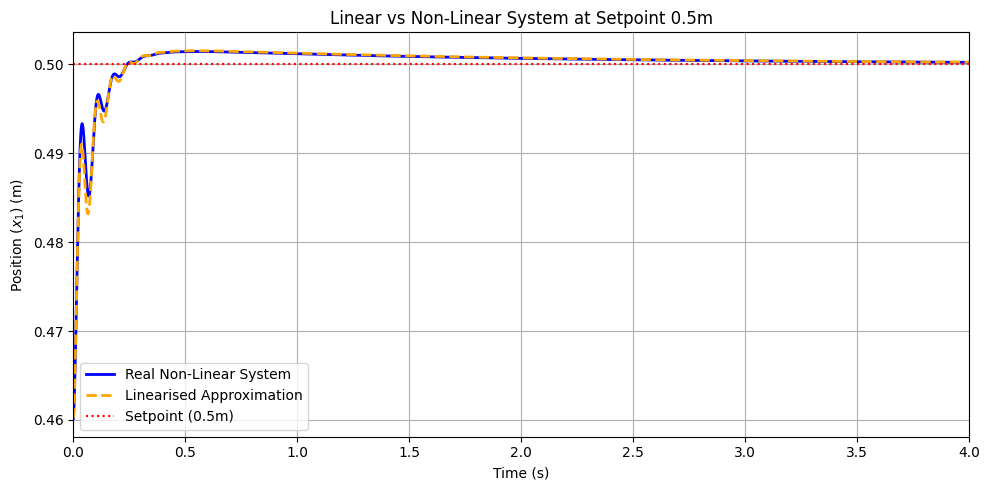

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

x_sp = 0.5  # Target Setpoint
start_x = x_sp - 0.04
t_sim = 4.0         # Force simulation to 4 seconds
dt = 0.001
time_steps = np.arange(0, t_sim, dt)

f_grav_spring = k*(x_sp - d) - m*g*np.sin(phi)
i_eq = np.sqrt(f_grav_spring * (delta - x_sp)**2 / c)
Lx_eq = L0 + L1 * np.exp(-alpha * (delta - x_sp))
V_eq = i_eq * R

a21 = (5 / (7 * m)) * ((2 * c * i_eq**2) / (delta - x_sp)**3 - k)
a22 = - (5 * b) / (7 * m)
a23 = (5 / (7 * m)) * ((2 * c * i_eq) / (delta - x_sp)**2)
a33 = - R / Lx_eq
a41 = Km / tau_m
a44 = - 1 / tau_m

A = np.array([[0, 1, 0, 0], [a21, a22, a23, 0], [0, 0, a33, 0], [a41, 0, 0, a44]])
B = np.array([[0], [0], [1 / Lx_eq], [0]])

def linear_dynamics(t, state_delta, V_input):
    delta_V = V_input - V_eq
    return A.dot(state_delta) + B.dot([delta_V]).flatten()

# Non-Linear Tracking
current_state = [start_x, 0, i_eq]
current_measured_x = start_x
history_x1 = []
integral_error = 0
last_error = 0

# Linear Tracking
current_state_delta = [start_x - x_sp, 0, 0, start_x - x_sp]
history_x_lin = []
integral_error_lin = 0
last_error_lin = 0

history_t_sync = []

for t in time_steps:
    # --- Simulate Real Non-Linear System ---
    actual_x = current_state[0]

    sensor_derivative = (Km * actual_x - current_measured_x) / tau_m
    current_measured_x += sensor_derivative * dt

    error = x_sp - current_measured_x
    integral_error += error * dt
    deriv = (error - last_error) / dt

    u = V_eq + Kp * error + Ki * integral_error + Kd * deriv
    u = np.clip(u, -100, 3000)

    sol = solve_ivp(system_dynamics, [t, t + dt], current_state, args=(u,))
    current_state = sol.y[:, -1]
    last_error = error
    history_x1.append(current_state[0])

    # --- Simulate Linearised System ---
    measured_x_lin = current_state_delta[3] + x_sp
    error_lin = x_sp - measured_x_lin
    integral_error_lin += error_lin * dt
    deriv_lin = (error_lin - last_error_lin) / dt

    V_control = V_eq + Kp * error_lin + Ki * integral_error_lin + Kd * deriv_lin
    V_control = np.clip(V_control, -100, 3000)

    sol_lin = solve_ivp(linear_dynamics, [t, t + dt], current_state_delta, args=(V_control,))
    current_state_delta = sol_lin.y[:, -1]
    last_error_lin = error_lin
    history_x_lin.append(current_state_delta[0] + x_sp)

    # Track time
    history_t_sync.append(t)

plt.figure(figsize=(10, 5))
plt.plot(history_t_sync, history_x1, label='Real Non-Linear System', color='blue', linewidth=2)
plt.plot(history_t_sync, history_x_lin, label='Linearised Approximation', color='orange', linestyle='--', linewidth=2)
plt.axhline(y=x_sp, color='r', linestyle=':', label=f'Setpoint ({x_sp}m)')

plt.ylabel('Position ($x_1$) (m)')
plt.xlabel('Time (s)')
plt.xlim(0, t_sim)
plt.title(f'Linear vs Non-Linear System at Setpoint {x_sp}m')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('nonli_vs_li_xsp0.5.png', dpi=300, bbox_inches='tight')
plt.show()